In [15]:
import pandas as pd

import plotly.express as px

dfs = []
for i in range(2, 8):
    df = pd.read_json(f'../results/quest/{i}.json')
    df['source'] = i
    df['hops'] = i - 1
    df['true_size_bytes'] = df['size_bytes'] * (i - 1)
    dfs.append(df)

# Concatenate DataFrames
df = pd.concat(dfs)

In [21]:
# Aggregate data by mean time_s for each size_bytes and source
df_agg = df.groupby(['true_size_bytes', 'source'])['time_s'].mean().reset_index()

# Create the plot
fig = px.line(df_agg, x='true_size_bytes', y='time_s', color='source', title='Bytes over Time (Mean)')
fig.show()

In [17]:
import pandas as pd
import statsmodels.api as sm

# df with columns: size_bytes, source, hops, time_s
df = df.copy()
df["p_minus_1"] = df["source"] - 1
df["bytes_term"] = df["p_minus_1"] * df["size_bytes"]

X = df[["p_minus_1", "bytes_term"]]  # drop "hops" if it's constant/noisy
# X = sm.add_constant(X)  # include intercept if you want to absorb fixed overheads
y = df["time_s"]

model = sm.OLS(y, X).fit()
print(model.summary())

alpha = model.params["p_minus_1"]         # seconds per step
inv_B = model.params["bytes_term"]        # seconds per byte
B_eff = 1.0 / inv_B                       # bytes per second
delta = model.params.get("hops", 0.0)

                                 OLS Regression Results                                
Dep. Variable:                 time_s   R-squared (uncentered):                   0.997
Model:                            OLS   Adj. R-squared (uncentered):              0.997
Method:                 Least Squares   F-statistic:                          1.754e+05
Date:                Thu, 16 Oct 2025   Prob (F-statistic):                        0.00
Time:                        16:34:48   Log-Likelihood:                          878.94
No. Observations:                1080   AIC:                                     -1754.
Df Residuals:                    1078   BIC:                                     -1744.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

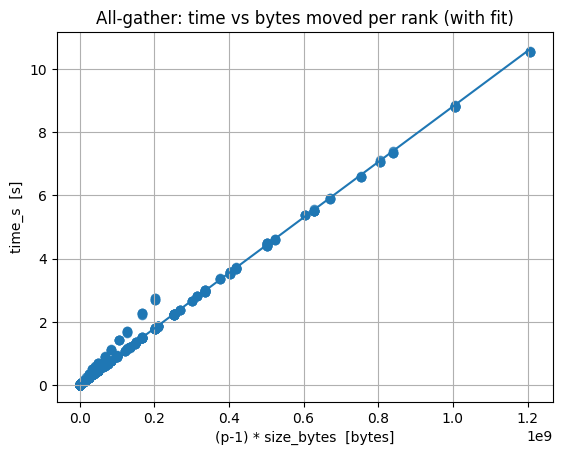

                            OLS Regression Results                            
Dep. Variable:                 time_s   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 2.978e+05
Date:                Thu, 16 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:34:48   Log-Likelihood:                 901.48
No. Observations:                1080   AIC:                            -1799.
Df Residuals:                    1078   BIC:                            -1789.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0242      0.004      6.856      0.0

In [18]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = df.copy()
df["p_minus_1"] = df["source"] - 1
df["bytes_term"] = df["p_minus_1"] * df["size_bytes"]

X = sm.add_constant(df[["bytes_term"]])
y = df["time_s"]
m = sm.OLS(y, X).fit()

# Predictions on sorted x for a clean line
xs = np.linspace(df["bytes_term"].min(), df["bytes_term"].max(), 100)
Xline = sm.add_constant(pd.DataFrame({"bytes_term": xs}))
yhat = m.predict(Xline)

plt.figure()
plt.scatter(df["bytes_term"], df["time_s"], alpha=0.7)
plt.plot(xs, yhat)
plt.xlabel("(p-1) * size_bytes  [bytes]")
plt.ylabel("time_s  [s]")
plt.title("All-gather: time vs bytes moved per rank (with fit)")
plt.grid(True)
plt.show()

print(m.summary())


In [ ]:
import pandas as pd
import statsmodels.api as sm
import json

with open('../results/.json', 'r') as f:
    orin_rtp_4_data = json.load(f)

# Assuming orin_rtp_4_data is a list of dicts with keys: total_transmit_duration, total_transmit_size, transmit_count
df_orin = pd.DataFrame(orin_rtp_4_data)

# Rename columns for consistency
df_orin['transmit_count'] = df_orin['transmit_count']
df_orin['time_s'] = df_orin['total_transmit_duration']
df_orin['bytes_term'] = df_orin['total_transmit_size'] * 3

# Use the model from CELL INDEX: 3 to predict
X_orin = sm.add_constant(df_orin[['bytes_term']])
# y_pred = m.predict(X_orin)
# y_pred = y_pred + df_orin['transmit_count'] * 0.0005 - 0.0211
y_pred = df_orin['transmit_count'] * 0.0006 + df_orin['bytes_term'] * 5.184e-09

# Compare predictions to actual
df_orin['predicted_time_s'] = y_pred
df_orin['error'] = df_orin['time_s'] - df_orin['predicted_time_s']
df_orin['abs_error'] = df_orin['error'].abs()

print("Predictions and errors:")
print(df_orin[['time_s', 'predicted_time_s', 'error', 'abs_error']])
print(f"Mean Absolute Error: {df_orin['abs_error'].mean()}")
print(f"Mean Percentage Error: {(df_orin['abs_error'] / df_orin['time_s']).mean() * 100:.2f}%")

Predictions and errors:
       time_s  predicted_time_s     error  abs_error
0    0.173220          0.163575  0.009646   0.009646
1    0.158598          0.163575 -0.004976   0.004976
2    0.157192          0.163575 -0.006382   0.006382
3    0.374108          0.234073  0.140035   0.140035
4    0.394733          0.234073  0.160660   0.160660
..        ...               ...       ...        ...
121  6.826698          4.016305  2.810393   2.810393
122  6.826239          4.016305  2.809935   2.809935
123  9.281651          4.768287  4.513364   4.513364
124  9.336526          4.768287  4.568239   4.568239
125  9.436175          4.768287  4.667888   4.667888

[126 rows x 4 columns]
Mean Absolute Error: 1.3838225492703786
Mean Percentage Error: 42.83%
